In [64]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt

### Inciso 1

In [65]:
A = np.array([[-0.25, -2, 0],
              [0.08, -0.35, 0],
              [0, 1, 0]])
B = np.array([[0],
              [0.62],
              [0]])
C = np.array([[0, 0, 1]])
D = np.array([[0]])

### Inciso 2

In [66]:
# Para que se pueda diseñar un controlador por realimentación de estados completo se debe encontrar la matriz de 
# controlabilidad y que su rango sea igual a la cantidad de estados, en este caso 3

Co = ctrl.ctrb(A, B)
print("Rango controlabilidad:", np.linalg.matrix_rank(C))

Rango controlabilidad: 1


### Inciso 3

In [67]:
A_ext = np.block([[A, np.zeros((3, 1))],
                  [-C, np.zeros((1, 1))]])
B_ext = np.vstack((B, [[0]]))
C_ext = np.hstack((C, np.zeros((1, 1))))
D_ext = D

### Inciso 4

In [68]:
# Para que se pueda diseñar un controlador por realimentación de estados completo se debe encontrar la matriz de 
# controlabilidad y que su rango sea igual a la cantidad de estados, en este caso 4

Co_ext = ctrl.ctrb(A_ext, B_ext)
print("Rango controlabilidad:", np.linalg.matrix_rank(Co_ext))

Rango controlabilidad: 4


### Inciso 5

In [69]:
polos_deseados = [-1.5, -2.0, -2.5, -3.0]
K_ext = ctrl.place(A_ext, B_ext, polos_deseados)
print("K extendido:", K_ext)

K extendido: [[-174.51814516   13.5483871  -304.83870968 -145.16129032]]


### Inciso 6

In [70]:
tramos = [
    (0,  10,  1000, 0),
    (10, 25,  1500, np.pi/6),
    (25, 40,  1500, -np.pi/6),
    (40, 60,  2000, np.pi/3),
]

psi_ref = np.array([])
for (_, _, n, ref) in tramos:
    psi_ref = np.concatenate([psi_ref, np.full(n, ref)])

In [71]:
def simular_sistema(polos):
    K_ext = ctrl.place(A_ext, B_ext, polos)
    Kx = K_ext[0, :3]
    Ki = K_ext[0, 3]
    Kx_mat = Kx.reshape(1, -1)

    A_cl = np.block([[A - B @ Kx_mat, -B * Ki],
                       [-C, np.zeros((1, 1))]])
    B_cl = np.vstack((np.zeros((3, 1)), [[1.0]]))
    sys_cl = ctrl.ss(A_cl, B_cl, C_ext, D_ext)

    t_total = []
    y_total = []
    x_total = []
    X0 = np.zeros(4)

    for (t_ini, t_fin, n_pts, ref) in tramos:
        t_tramo = np.linspace(t_ini, t_fin, n_pts)
        t_out, y_out, x_out = ctrl.forced_response(sys_cl, T=t_tramo, U=ref, X0=X0, return_x=True)
        t_total.append(t_out)
        y_total.append(y_out)
        x_total.append(x_out)
        X0 = x_out[:, -1]

    t_total = np.concatenate(t_total)
    y_total = np.concatenate(y_total, axis=-1)
    x_total = np.concatenate(x_total, axis=-1)

    tau_r = -(Kx @ x_total[:3, :]) + Ki * x_total[3, :]

    return t_total, y_total, x_total, tau_r, Kx, Ki

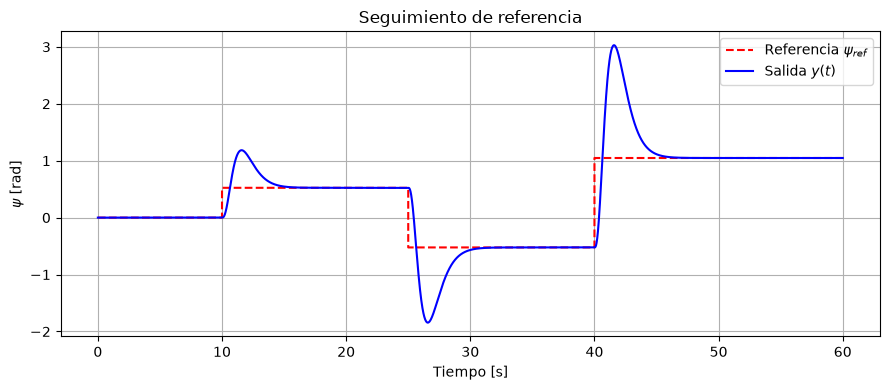

In [72]:
# Sistema en lazo cerrado
t1, y1, x1, tau1, Kx1, Ki1 = simular_sistema(polos_deseados)

# Salida vs referencia
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t1, psi_ref, 'r--', label='Referencia $\\psi_{ref}$')
ax.plot(t1, y1, 'b-',  label='Salida $y(t)$')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('$\\psi$ [rad]')
ax.set_title('Seguimiento de referencia')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Inciso 7

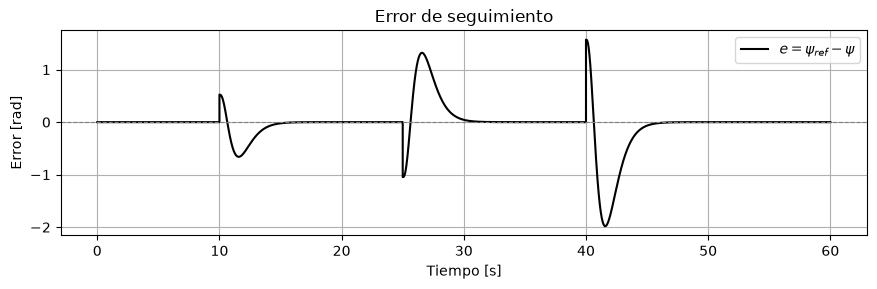

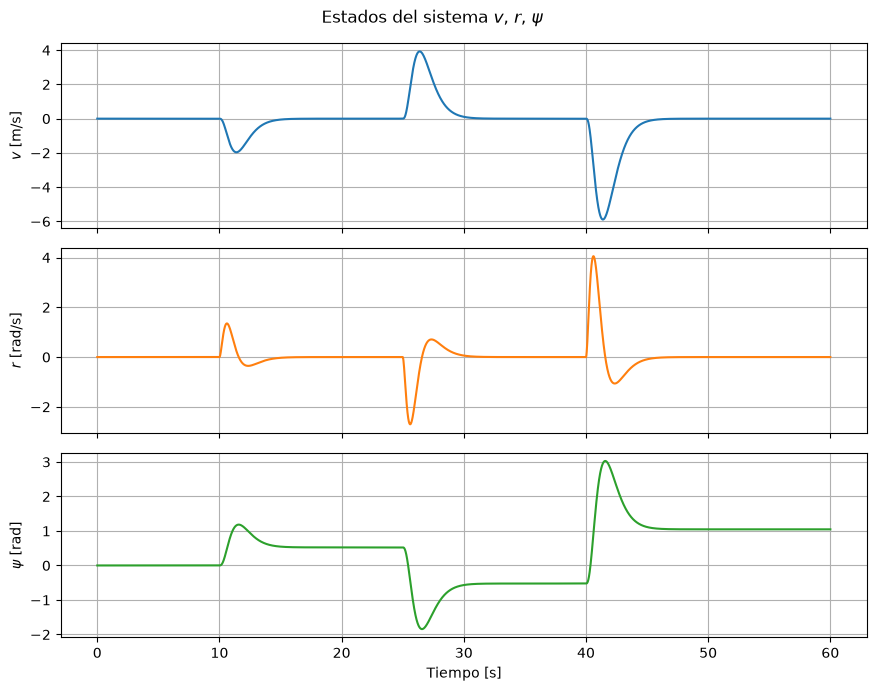

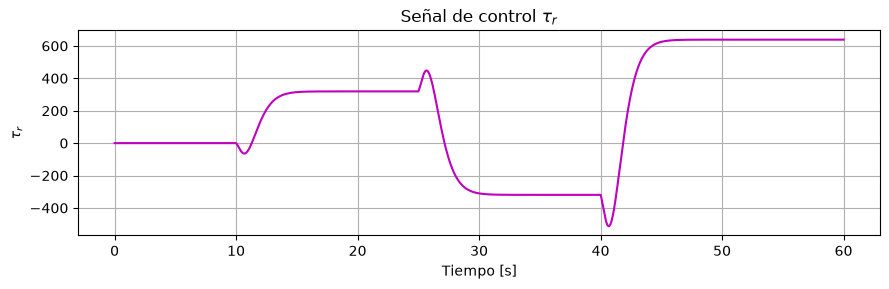

In [73]:
error = psi_ref - y1 # Error de seguimiento

# Error de seguimiento
fig1, ax1 = plt.subplots(figsize=(9, 3))
ax1.plot(t1, error, 'k-', label='$e = \\psi_{ref} - \\psi$')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Error [rad]')
ax1.set_title('Error de seguimiento')
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()

nombres_estados = [
    ('$v$ [m/s]', 'tab:blue'),
    ('$r$ [rad/s]', 'tab:orange'),
    ('$\\psi$ [rad]', 'tab:green'),
]

fig2, axes2 = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for i, (nombre, color) in enumerate(nombres_estados):
    axes2[i].plot(t1, x1[i], color=color)
    axes2[i].set_ylabel(nombre)
    axes2[i].grid(True)
axes2[-1].set_xlabel('Tiempo [s]')
fig2.suptitle('Estados del sistema $v$, $r$, $\\psi$')
plt.tight_layout()
plt.show()

# Señal de control tau_r
fig3, ax3 = plt.subplots(figsize=(9, 3))
ax3.plot(t1, tau1, 'm-')
ax3.set_xlabel('Tiempo [s]')
ax3.set_ylabel('$\\tau_r$')
ax3.set_title('Señal de control $\\tau_r$')
ax3.grid(True)
plt.tight_layout()
plt.show()

Con los polos originales: Kx = [-174.51814516   13.5483871  -304.83870968], Ki = -145.1613
Con los polos rapidos: Kx = [-3634.19556445    28.06451613 -7083.87096762], Ki = -2322.5806


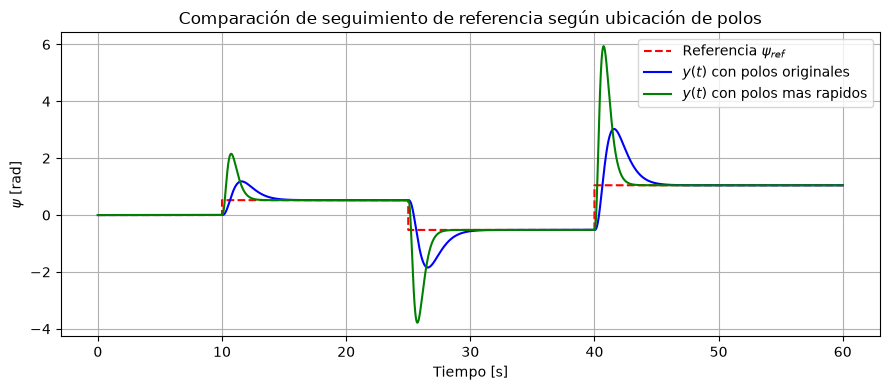

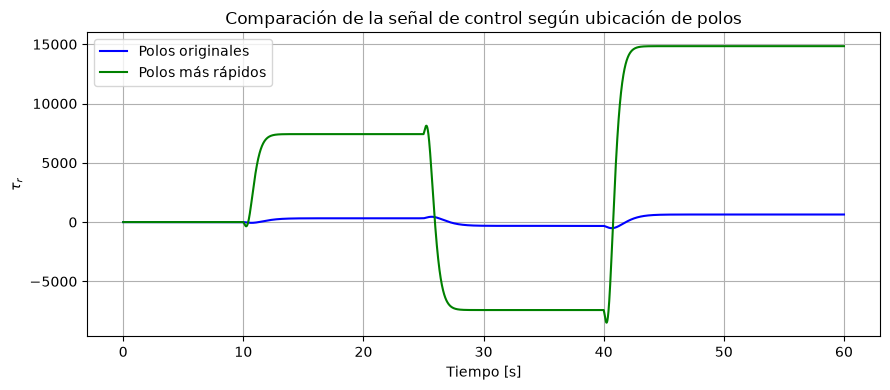

Módulo del pico máximo de tau_r con los polos originales: 638.45
Módulo del pico máximo de tau_r con los polos rapidos: 14836.42


In [79]:
polos_rapidos    = [-3.0, -4.0, -5.0, -6.0]
t2, y2, x2, tau2, Kx2, Ki2 = simular_sistema(polos_rapidos)

print(f"Con los polos originales: Kx = {Kx1}, Ki = {Ki1:.4f}")
print(f"Con los polos rapidos: Kx = {Kx2}, Ki = {Ki2:.4f}")

# Comparacion de seguimiento de referencia
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t1, psi_ref, 'r--', label='Referencia $\\psi_{ref}$')
ax.plot(t1, y1, 'b-', label='$y(t)$ con polos originales')
ax.plot(t2, y2, 'g-', label='$y(t)$ con polos mas rapidos')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('$\\psi$ [rad]')
ax.set_title('Comparación de seguimiento de referencia según ubicación de polos')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Comparación de la señal de control
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t1, tau1, 'b-', label='Polos originales')
ax.plot(t2, tau2, 'g-', label='Polos más rápidos')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('$\\tau_r$')
ax.set_title('Comparación de la señal de control según ubicación de polos')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Módulo del pico máximo de tau_r con los polos originales: {np.max(np.abs(tau1)):.2f}")
print(f"Módulo del pico máximo de tau_r con los polos rapidos: {np.max(np.abs(tau2)):.2f}")